## Question 3

In [1]:
from mqf_hw1.data import load_data
import matplotlib.pyplot as plt

df = load_data()
df.head()

,date,us_stocks,intl_stocks,10-yr T-bond,3m T-bill,cpi_inflation
0,1970-01-31,-0.075398,-0.021370,0.028827,0.007158,0.002653
1,1970-02-28,0.059521,-0.013008,0.067886,0.007986,0.005291
2,1970-03-31,0.002806,-0.000932,-0.000269,0.007078,0.005263
3,1970-04-30,-0.088831,-0.105223,-0.050871,0.005494,0.007853
4,1970-05-31,-0.054689,-0.074294,-0.006522,0.006237,0.002597


In [2]:
import numpy as np
import pandas as pd

print(df.columns.tolist())  # should be date, us_stocks, intl_stocks, bond, bill, cpi

d = df.copy()
d = d.set_index(d.columns[0])
d.columns = ["us", "intl", "bond", "bill", "cpi"]
d.index = pd.to_datetime(d.index)

# real returns
real = d[["us", "intl", "bond", "bill"]].add(1).div(1 + d["cpi"], axis=0) - 1

# Q2 benchmark portfolios (fixed weights, monthly rebalanced)
port = pd.DataFrame({
    "100% T-bills": real["bill"],
    "100% US stocks": real["us"],
    "60/40 stock/bond": 0.6 * real["us"] + 0.4 * real["bond"],
    "34/66 US/Intl": 0.34 * real["us"] + 0.66 * real["intl"],
})
port.tail()

['date', 'us_stocks', 'intl_stocks', '10-yr T-bond', '3m T-bill', 'cpi_inflation']


,100% T-bills,100% US stocks,60/40 stock/bond,34/66 US/Intl
date,,,,
2026-03-31,-0.007327,-0.059659,-0.049081,-0.090741
2026-04-30,-0.005385,0.095613,0.052224,0.075320
2026-05-31,-0.003192,0.046027,0.024998,0.029935
2026-06-30,0.006304,-0.006050,-0.000455,-0.000876
2026-07-31,0.003438,-0.000533,-0.008503,0.013502


In [3]:
def max_drawdown(r):
    wealth = (1 + r).cumprod()
    wealth = pd.concat([pd.Series([1.0], index=[r.index[0] - pd.offsets.MonthEnd(1)]), wealth])
    dd = wealth / wealth.cummax() - 1
    trough = dd.idxmin()
    peak = wealth.loc[:trough].idxmax()
    return dd.min(), peak, trough, dd

rows, dd_paths = [], {}
for name in port:
    mdd, pk, tr, dd = max_drawdown(port[name])
    rows.append({"Portfolio": name, "Max drawdown": mdd,
                 "Peak": pk.strftime("%Y-%m"), "Trough": tr.strftime("%Y-%m")})
    dd_paths[name] = dd

table_a = pd.DataFrame(rows).set_index("Portfolio")
table_a.style.format({"Max drawdown": "{:.1%}"})

,Max drawdown,Peak,Trough
Portfolio,,,
100% T-bills,-23.9%,2008-12,2022-06
100% US stocks,-52.9%,2000-08,2009-02
60/40 stock/bond,-38.7%,1972-12,1974-09
34/66 US/Intl,-55.2%,2007-10,2009-02


In [4]:
roll = pd.DataFrame({
    n: np.expm1(np.log1p(port[n]).rolling(120).sum()).dropna() for n in port
})

table_b = pd.DataFrame({
    "Mean": roll.mean(),
    "5th pct": roll.quantile(0.05),
    "Median": roll.median(),
    "95th pct": roll.quantile(0.95),
})
table_b.style.format("{:.1%}")

,Mean,5th pct,Median,95th pct
100% T-bills,13.6%,-13.2%,12.7%,55.4%
100% US stocks,126.2%,-22.4%,134.5%,288.7%
60/40 stock/bond,90.5%,-10.9%,81.5%,196.6%
34/66 US/Intl,91.1%,-12.4%,68.2%,243.2%


In [5]:
p5 = table_b["5th pct"]
print(f"5th pct, global all-equity (34/66): {p5['34/66 US/Intl']:.1%}")
print(f"5th pct, 60/40 balanced:            {p5['60/40 stock/bond']:.1%}")
print("Global has the higher 5th percentile:", p5['34/66 US/Intl'] > p5['60/40 stock/bond'])

5th pct, global all-equity (34/66): -12.4%
5th pct, 60/40 balanced:            -10.9%
Global has the higher 5th percentile: False


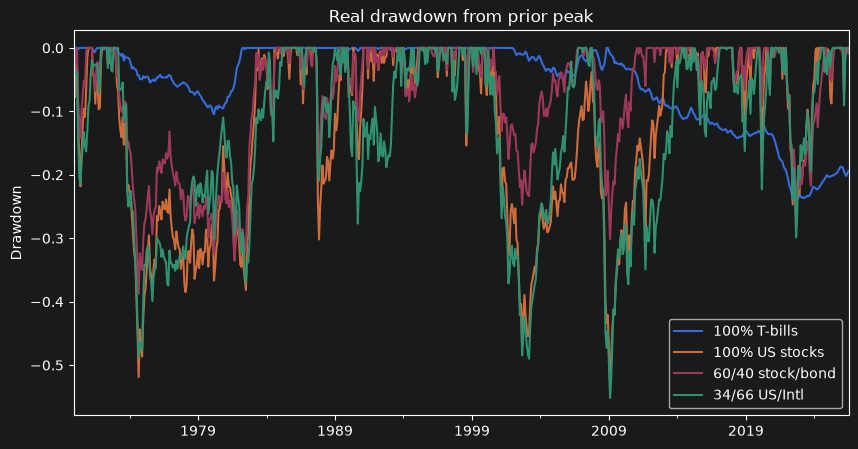

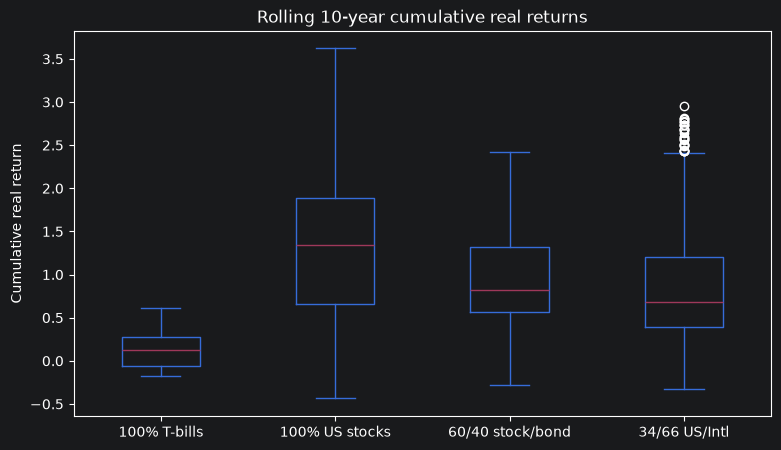

In [6]:
pd.DataFrame(dd_paths).plot(figsize=(10, 5), title="Real drawdown from prior peak")
plt.ylabel("Drawdown")
plt.show()

roll.plot.box(figsize=(9, 5), title="Rolling 10-year cumulative real returns")
plt.ylabel("Cumulative real return")
plt.show()

### Q3 discussion

**(a)** The 60/40 portfolio had the smallest real drawdown of the stock-based portfolios (-38.7%, 1972-12 to 1974-09). The globally diversified all-equity portfolio had the largest (-55.2%, 2007-10 to 2009-02), slightly worse than US stocks alone (-52.9%). Even T-bills lost about 24% in real terms (2008-12 to 2022-06) because inflation outran their yield.

**(b)** Over rolling 10-year windows, the global portfolio's mean cumulative real return (91.1%) is about the same as 60/40's (90.5%), but its median is lower (68.2% vs 81.5%) and its 95th percentile is higher (243.2% vs 196.6%). US stocks have the highest mean (126.2%) but the worst 5th percentile (-22.4%).

**(c)** No. The global all-equity portfolio's 5th percentile (-12.4%) is slightly worse than 60/40's (-10.9%), so my sample does not reproduce the paper's Table V result. Caveats: (i) the sample is under 57 years, so there are only about five non-overlapping 10-year periods and the 560 overlapping windows are heavily autocorrelated; (ii) it includes the 1982-2020 bond bull market, which flatters bonds, and a US-dominated equity market; (iii) international returns are dominated by a few episodes such as Japan's boom and bust; (iv) the paper's 130+ years span wars, hyperinflations and bond crashes that this sample never sees.